# W1D4 extra — Decision Trees & Random Forests — Lab

**Week 1 · Day 4 · Foundations** · Extra lab · optional

Logistic regression drew one straight line and asked the data to live with it. A decision tree does
something a person can read out loud instead: ask a question about one column, split the customers in
two, then ask again. Today you grow one two questions deep and read it as plain English, watch what
happens when you let it grow ten questions deep, then plant two hundred of them and see whether the
crowd beats the individual.

Nothing here is new mathematics. It is the same churn data and the same accuracy score you already
know, with a model you can print.

**Time budget:** ~55 minutes. This lab is optional extra practice for Day 4.

<div dir="rtl" align="right">

# الأسبوع ١ اليوم ٤ إضافي — أشجار القرار والغابات العشوائية

**الأسبوع ١ · اليوم ٤ · الأساسيات** · معمل إضافي · اختياري

الانحدار اللوجستي رسم خطًّا مستقيمًا واحدًا وطلب من البيانات أن تتعايش معه. أما شجرة القرار فتفعل
شيئًا يستطيع الإنسان أن يقرأه بصوت عالٍ: تسأل سؤالًا عن عمود واحد، فتقسم العملاء إلى قسمين، ثم تسأل
مرة أخرى. اليوم تُنمّي شجرة بعمق سؤالين وتقرأها كلامًا عاديًا، ثم ترى ما يحدث حين تتركها تنمو إلى
عشرة أسئلة، ثم تزرع مئتي شجرة وترى هل يتفوّق الجمع على الفرد.

لا شيء هنا رياضيات جديدة. إنها بيانات المغادرة نفسها ومقياس الدقة نفسه الذي تعرفه، مع نموذج يمكن
طباعته.

**الزمن المتوقّع:** نحو ٥٥ دقيقة. هذا المعمل إضافي اختياري لليوم الرابع.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Read a fitted decision tree as a chain of if-then questions, in words.
- Show, with one plot, the depth at which a tree stops learning and starts memorising.
- Fit a random forest and say in one sentence why many shallow disagreeing trees beat one deep one.
- Rank the columns by how much the model leans on them, and say what that ranking does not prove.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- أن تقرأ شجرة قرار مُدرَّبة كسلسلة أسئلة «إذا… فإنّ…» بالكلمات.
- أن تُظهر برسم واحد العمق الذي تتوقّف عنده الشجرة عن التعلّم وتبدأ الحفظ.
- أن تُدرّب غابة عشوائية وتقول في جملة واحدة لماذا تتفوّق أشجار كثيرة ضحلة ومختلفة على شجرة واحدة عميقة.
- أن تُرتّب الأعمدة بحسب اعتماد النموذج عليها، وأن تقول ما الذي لا يُثبته هذا الترتيب.

</div>

## About the data

**Dataset:** `telco_churn` — IBM's public telecom sample · CC0 (public domain) · 7,043 rows

The same customers as Day 3, with four numeric columns instead of two: `tenure`, `MonthlyCharges`,
`TotalCharges` and `SeniorCitizen`. The label is `Churn` — did the customer leave. About 26.5% did, so
"nobody leaves" is already right 73.5% of the time, and that is the number every model here has to beat.

**Watch out:** `TotalCharges` is stored as text and is blank for the eleven customers whose tenure is
zero. The setup cell converts it to a number and fills those blanks with 0.0 — they have been billed
nothing yet, so zero is the honest value.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `telco_churn` — عيّنة اتصالات عامة من IBM · رخصة CC0 · ٧٠٤٣ صفًّا

العملاء أنفسهم من اليوم الثالث، لكن بأربعة أعمدة رقمية بدل عمودين: `tenure` و`MonthlyCharges`
و`TotalCharges` و`SeniorCitizen`. والتسمية هي `Churn` — هل غادر العميل الخدمة. نحو ٢٦٫٥٪ غادروا،
فالتنبّؤ بأن «لا أحد يغادر» صحيح أصلًا في ٧٣٫٥٪ من الحالات، وهذا هو الرقم الذي يجب أن يتفوّق عليه كل
نموذج هنا.

**انتبه:** العمود `TotalCharges` مخزّن كنص ويكون فارغًا لأحد عشر عميلًا مدّة اشتراكهم صفر. وخلية
التهيئة تحوّله إلى رقم وتملأ تلك الفراغات بالقيمة ٠٫٠ — فهؤلاء لم تُصدر لهم فاتورة بعد، والصفر هو
القيمة الصادقة.

</div>

## Setup

Run the cell below first. It installs anything missing, fixes the random seed, loads the four numeric
columns and the label, and splits them 80/20 with the churn rate preserved in both halves — the same
split you made by hand yesterday, done for you so today stays about trees.

`X_train` and `X_test` are pandas DataFrames, not NumPy arrays, so the column names survive all the way
to the feature-importance plot.

<div dir="rtl" align="right">

## التهيئة

شغّل الخلية أدناه أولًا. تُثبّت ما ينقص، وتُثبّت البذرة العشوائية، وتُحمّل الأعمدة الرقمية الأربعة
والتسمية، وتقسمها ٨٠ / ٢٠ مع الحفاظ على نسبة المغادرين في النصفين — وهو التقسيم نفسه الذي كتبته بيدك
أمس، جاهزًا هنا ليبقى اليوم عن الأشجار وحدها.

المتغيّران `X_train` و`X_test` هما DataFrame من pandas لا مصفوفتَي NumPy، لكي تبقى أسماء الأعمدة حتى
رسم أهمية الخصائص.

</div>

In [ ]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset, describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("scikit-learn", "matplotlib")
seed_everything(42)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from aiep.viz import use_course_style
use_course_style()

DATA = get_dataset("telco_churn")
_df = pd.read_parquet(DATA)

FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
X = _df.assign(
    TotalCharges=pd.to_numeric(_df["TotalCharges"], errors="coerce").fillna(0.0)
)[FEATURES]
y = (_df["Churn"] == "Yes").astype(int).to_numpy()      # 1 = the customer left

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

MAJORITY = float(1 - y_test.mean())    # accuracy of always saying "nobody leaves"

print(describe_dataset("telco_churn"))
print(f"\ntrain {X_train.shape[0]:,} rows | test {X_test.shape[0]:,} rows | "
      f"churn rate {y.mean():.4f}")
print(f"always-say-no baseline on the test set: {MAJORITY:.4f}")
print("\n", versions())

⬇️  Downloading telco_churn.parquet (0.2 MB) …
✅ telco_churn: downloaded to /content/aiep_data/telco_churn.parquet
telco_churn  (7043 rows, 0.2 MB)
  Source:  https://www.kaggle.com/datasets/blastchar/telco-customer-churn
  Licence: CC0 (public domain)
  Target:  Churn

  EN: Telecom customer records with a churn label. Mixed numeric and categorical columns, a genuinely imbalanced target (~27% churn), and enough messiness to carry the whole of weeks 1-3 without students restarting on a new dataset every day.
  AR: سجلات عملاء اتصالات مع عمود يوضّح مغادرة العميل للخدمة. أعمدة رقمية وفئوية مختلطة، وهدف غير متوازن فعليًا (نحو ٢٧٪)، وفيها من الفوضى ما يكفي لتغطية الأسابيع الثلاثة الأولى دون أن يبدأ الطلاب من مجموعة بيانات جديدة كل يوم.

  ⚠️  Watch out: TotalCharges is stored as text and is blank for customers with tenure = 0.
  ⚠️  انتبه: عمود TotalCharges مخزّن كنص ويكون فارغًا للعملاء الذين مدّة اشتراكهم صفر.

train 5,634 rows | test 1,409 rows | churn rate 0.2654
always-say-no baseline

## Section 1 — Warm-up: a tree you can read  (≈10 min)

A tree of depth 2 asks at most two questions before it answers. That is small enough to print, and
printing it is the whole point: this is the one model in the course whose reasoning you can check line
by line without trusting anybody.

<div dir="rtl" align="right">

## القسم الأول — الإحماء: شجرة تستطيع قراءتها (نحو ١٠ دقائق)

الشجرة بعمق ٢ تسأل سؤالين على الأكثر قبل أن تُجيب. وهذا صغير بما يكفي لطباعته، والطباعة هي المقصد
كلّه: هذا هو النموذج الوحيد في الدورة الذي يمكنك التحقّق من استدلاله سطرًا سطرًا دون أن تثق بأحد.

</div>

### Task 1.1 — grow a tree two questions deep, then read it

Fit a `DecisionTreeClassifier` with `max_depth=2` on the training half and print it with `export_text`.

Then read one path aloud, in words: *"if tenure is below X and monthly charges are above Y, predict
churn."* If you cannot say it in a sentence, you have not read it yet.

<div dir="rtl" align="right">

### المهمة ١٫١ — أنمِ شجرة بعمق سؤالين ثم اقرأها

درّب `DecisionTreeClassifier` بالوسيط `max_depth=2` على نصف التدريب واطبعها بـ`export_text`.

ثم اقرأ مسارًا واحدًا بصوت عالٍ وبالكلمات: «إذا كانت مدّة الاشتراك أقل من كذا والرسوم الشهرية أعلى من
كذا، فتنبّأ بالمغادرة». وإذا لم تستطع قولها في جملة فأنت لم تقرأها بعد.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) DecisionTreeClassifier lives in sklearn.tree, next to export_text.
# 2) Pass max_depth=2 and random_state=42, then .fit(X_train, y_train). Call it `small_tree`.
# 3) export_text needs feature_names=FEATURES, or it prints "feature_0" and tells you nothing.
# Search: "sklearn DecisionTreeClassifier export_text feature_names"
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
#
# ١) الصنف DecisionTreeClassifier موجود في sklearn.tree بجوار export_text.
# ٢) مرّر max_depth=2 وrandom_state=42 ثم .fit(X_train, y_train)، وسمِّها `small_tree`.
# ٣) تحتاج export_text إلى feature_names=FEATURES وإلا طبعت "feature_0" ولم تُفدك بشيء.
# ابحث عن: "sklearn DecisionTreeClassifier export_text feature_names"
# ────────────────────────────────────────────────────────────────────

from sklearn.tree import DecisionTreeClassifier, export_text
# TODO: Fit a depth-2 decision tree on the training half and call it `small_tree`.
# مهمة: درّب شجرة قرار بعمق ٢ على نصف التدريب وسمِّها `small_tree`.
small_tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
).fit(X_train, y_train)

print(export_text(small_tree, feature_names=FEATURES))
print(f"test accuracy {small_tree.score(X_test, y_test):.4f} "
      f"vs baseline {MAJORITY:.4f}")

|--- tenure <= 16.50
|   |--- MonthlyCharges <= 67.88
|   |   |--- class: 0
|   |--- MonthlyCharges >  67.88
|   |   |--- class: 1
|--- tenure >  16.50
|   |--- MonthlyCharges <= 73.62
|   |   |--- class: 0
|   |--- MonthlyCharges >  73.62
|   |   |--- class: 0

test accuracy 0.7807 vs baseline 0.7346


In [ ]:
# The tree found tenure to be a useful first splitting feature for predicting churn.

Two questions, and it is already about five points above the baseline. `tenure` is the first split,
because new customers leave and long-standing ones do not, and the tree found that on its own from a
column of numbers, with nobody telling it that loyalty exists.

Notice what the print gives you that no coefficient ever did: an actual threshold. Not "tenure matters
negatively" but "tenure at or below 16.5 months, and monthly charges above 67.88 — predict churn". That
is a sentence you can hand to a retention team without translating it first.

<div dir="rtl" align="right">

سؤالان فقط، وهي بالفعل أعلى من خط الأساس بنحو خمس نقاط. والعمود `tenure` هو أول انقسام، لأن العملاء
الجدد يغادرون والقدامى لا يغادرون، والشجرة وجدت ذلك وحدها من عمود أرقام، دون أن يخبرها أحد بوجود شيء
اسمه الولاء.

ولاحظ ما تمنحك إياه هذه الطباعة ولم يمنحه أي معامل من قبل: عتبة فعلية. لا «مدّة الاشتراك مهمّة سلبًا»
بل «مدّة اشتراك ١٦٫٥ شهرًا أو أقل مع رسوم شهرية أعلى من ٦٧٫٨٨ — تنبّأ بالمغادرة». وهذه جملة تُسلّمها
لفريق الاحتفاظ بالعملاء دون أن تترجمها أولًا.

</div>

## Section 2 — Core: depth, and why one tree is not enough  (≈35 min)

A tree that is allowed to keep asking questions will eventually ask enough of them to separate every
single training customer perfectly. That model is useless, and this section is about seeing that happen
rather than being told about it.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: العمق، ولماذا لا تكفي شجرة واحدة (نحو ٣٥ دقيقة)

الشجرة التي يُسمح لها بمواصلة طرح الأسئلة ستطرح في النهاية ما يكفي منها لتفصل كل عميل تدريب على حدة
فصلًا تامًّا. وذلك النموذج بلا فائدة، وهذا القسم عن أن ترى ذلك يحدث لا أن يُقال لك عنه.

</div>

### Task 2.1 — the depth sweep

Fit one tree per depth from 1 to 10. Record the accuracy on the **training** half and on the **test**
half each time, then plot both curves on the same axes.

Store the best test depth in `best_depth` — the next task uses it.

<div dir="rtl" align="right">

### المهمة ٢٫١ — مسح الأعماق

درّب شجرة لكل عمق من ١ إلى ١٠. وسجّل في كل مرة الدقة على نصف **التدريب** وعلى نصف **الاختبار**، ثم
ارسم المنحنيين على المحاور نفسها.

واحفظ أفضل عمق على الاختبار في `best_depth` — فالمهمة التالية تستخدمه.

</div>

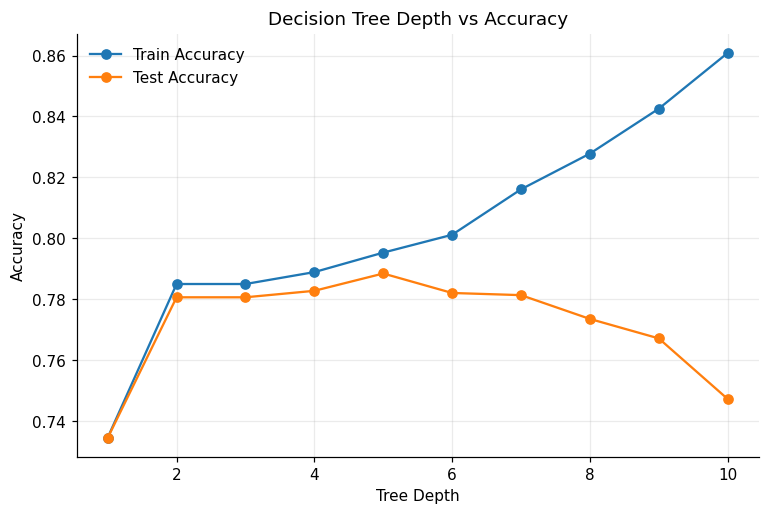

best depth on the test set: 5 (test accuracy 0.7885)
at depth 10: train 0.8608 | test 0.7473


In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Loop over DEPTHS. Inside the loop: fit a tree at that depth, then score it twice —
#    once on (X_train, y_train) and once on (X_test, y_test). A fitted model has .score().
# 2) Collect the two numbers into `train_scores` and `test_scores`, in depth order.
# 3) Plot both against list(DEPTHS) on one axes, with a legend. Label the axes.
# 4) best_depth is the depth at the highest test score — np.argmax gives you its position.
# Search: "numpy argmax index of maximum"
#
# ١) كرّر على DEPTHS. وداخل الحلقة: درّب شجرة بذلك العمق ثم قيّمها مرّتين —
#    مرة على (X_train, y_train) ومرة على (X_test, y_test). فللنموذج المُدرَّب دالة ‎.score()‎.
# ٢) اجمع الرقمين في `train_scores` و`test_scores` بترتيب الأعماق.
# ٣) ارسم المنحنيين مقابل list(DEPTHS) على محاور واحدة مع مفتاح، وسمِّ المحورين.
# ٤) `best_depth` هو العمق عند أعلى نتيجة اختبار — وnp.argmax تعطيك موضعه.
# ابحث عن: "numpy argmax index of maximum"
# ────────────────────────────────────────────────────────────────────

DEPTHS = range(1, 11)
# TODO: Fit one tree per depth, record train and test accuracy, plot both curves, and set best_depth.
# مهمة: درّب شجرة لكل عمق، وسجّل دقّة التدريب والاختبار، وارسم المنحنيين، واضبط best_depth.

train_scores = []
test_scores = []

for depth in DEPTHS:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    tree.fit(X_train, y_train)

    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(list(DEPTHS), train_scores, marker="o", label="Train Accuracy")
plt.plot(list(DEPTHS), test_scores, marker="o", label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy")
plt.legend()
plt.show()

best_depth = list(DEPTHS)[np.argmax(test_scores)]

print(f"best depth on the test set: {best_depth} "
      f"(test accuracy {max(test_scores):.4f})")
print(f"at depth 10: train {train_scores[-1]:.4f} | "
      f"test {test_scores[-1]:.4f}")

In [ ]:
# My observation: Test accuracy peaked at depth 5 (78.85%).
# At depth 10, training accuracy increased to 86.08% while test accuracy dropped to 74.73%, showing overfitting.

The two curves leave each other, and the gap between them is the whole lesson. Training accuracy
climbs forever, because a deeper tree can always carve out one more little box containing one more
training customer. Test accuracy peaks early and then sags.

Everything to the right of the peak is memorisation. The tree is learning which specific customers were
in the training file, and that knowledge is worth exactly nothing on a customer it has not met.

<div dir="rtl" align="right">

يفترق المنحنيان، والفجوة بينهما هي الدرس كلّه. فدقّة التدريب تصعد بلا نهاية، لأن الشجرة الأعمق تستطيع
دائمًا أن تقتطع صندوقًا صغيرًا آخر يضمّ عميل تدريب آخر. أما دقّة الاختبار فتبلغ ذروتها مبكرًا ثم تهبط.

وكل ما يقع يمين الذروة حفظ لا تعلّم. فالشجرة تتعلّم أي عملاء بعينهم كانوا في ملف التدريب، وتلك معرفة لا
تساوي شيئًا أمام عميل لم تره من قبل.

</div>

### Task 2.2 — two hundred trees instead of one

A random forest fits many trees, each on a random sample of the rows and allowed to consider only a
random subset of the columns at each split, then takes a vote. The trees disagree on purpose; the
disagreement is what cancels out each tree's private mistakes.

Fit `RandomForestClassifier(n_estimators=200, max_depth=best_depth, random_state=42)` — the same depth
limit as the single tree, so the only thing that changes is the number of trees — and compare three
accuracies: the baseline, one tree at `best_depth`, and the forest.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — مئتا شجرة بدل شجرة

الغابة العشوائية تُدرّب أشجارًا كثيرة، كلٌّ منها على عيّنة عشوائية من الصفوف ولا يُسمح لها إلا بالنظر
في مجموعة عشوائية جزئية من الأعمدة عند كل انقسام، ثم تُجري تصويتًا. والأشجار تختلف عن قصد؛ والاختلاف هو
ما يُلغي أخطاء كل شجرة الخاصة.

درّب `RandomForestClassifier(n_estimators=200, max_depth=best_depth, random_state=42)` — بحدّ العمق
نفسه المستخدم في الشجرة الواحدة، حتى يكون المتغيّر الوحيد هو عدد الأشجار — وقارن ثلاث دقّات: خط
الأساس، وشجرة واحدة عند `best_depth`، والغابة.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) RandomForestClassifier is in sklearn.ensemble. Fit it like the tree, and give it the
#    same max_depth=best_depth so the comparison isolates one thing: how many trees.
# 2) Also refit a single tree at best_depth so the comparison is fair — same data, same seed.
# 3) Store the two test accuracies as `tree_accuracy` and `forest_accuracy`; later cells use them.
# 4) The forest takes a second or two. That is 200 trees, so it is earning it.
# Search: "sklearn RandomForestClassifier n_estimators fit score"
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
#
# ١) الصنف RandomForestClassifier في sklearn.ensemble، ويُدرَّب كالشجرة، وأعطِه حدّ العمق
#    نفسه max_depth=best_depth ليعزل المقارنة على شيء واحد: عدد الأشجار.
# ٢) أعِد أيضًا تدريب شجرة واحدة عند best_depth لتكون المقارنة عادلة — البيانات نفسها والبذرة نفسها.
# ٣) خزّن دقّتَي الاختبار باسمي `tree_accuracy` و`forest_accuracy`؛ فالخلايا التالية تستخدمهما.
# ٤) تستغرق الغابة ثانية أو ثانيتين. فهي مئتا شجرة، وهي تستحقّ ذلك.
# ابحث عن: "sklearn RandomForestClassifier n_estimators fit score"
# ────────────────────────────────────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier
# TODO: Fit a 200-tree forest capped at best_depth, refit one tree at best_depth, and score both on the test half.
# مهمة: درّب غابة من ٢٠٠ شجرة بحدّ عمق best_depth، وأعِد تدريب شجرة واحدة عند best_depth، وقيّم كليهما على نصف الاختبار.

forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=best_depth,
    random_state=42
)

forest.fit(X_train, y_train)

one_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

one_tree.fit(X_train, y_train)

tree_accuracy = one_tree.score(X_test, y_test)
forest_accuracy = forest.score(X_test, y_test)

print(f"always say no        : {MAJORITY:.4f}")
print(f"one tree, depth {best_depth:<2}   : {tree_accuracy:.4f}")
print(f"forest of 200 trees  : {forest_accuracy:.4f}")

always say no        : 0.7346
one tree, depth 5    : 0.7885
forest of 200 trees  : 0.7949


In [ ]:
# Observation: The Random Forest performed slightly better than a single tree,
# but the small improvement shows that model complexity alone cannot solve the limitations of the available features.

Read the three numbers before you celebrate. The forest beats the single tree, and both beat the
baseline — but the margins are small, and small margins on 1,409 test customers are a handful of people.
A percentage point here is fourteen customers.

That is the honest summary of this dataset with four numeric columns: it has some signal, and not much.
The model is not the bottleneck; the columns are. That is why Week 2 is about data and not about models.

<div dir="rtl" align="right">

اقرأ الأرقام الثلاثة قبل أن تحتفل. الغابة تتفوّق على الشجرة الواحدة، وكلتاهما تتفوّق على خط الأساس —
لكن الفوارق صغيرة، والفارق الصغير على ١٤٠٩ عملاء اختبار يعني أفرادًا معدودين. فنقطة مئوية واحدة هنا
تساوي أربعة عشر عميلًا.

وهذا هو التلخيص الصادق لهذه البيانات بأربعة أعمدة رقمية: فيها بعض الإشارة، وليس كثيرًا. والنموذج ليس
هو العائق، بل الأعمدة هي العائق. ولهذا كان الأسبوع الثاني عن البيانات لا عن النماذج.

</div>

### Task 2.3 — what the forest leans on

Every fitted forest carries `feature_importances_`: one number per column, all four adding to 1,
measuring how much of the forest's splitting work that column did.

Put them in a `pd.Series` indexed by `FEATURES`, sort it, and draw a horizontal bar chart.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — على ماذا تتّكئ الغابة

كل غابة مُدرَّبة تحمل `feature_importances_`: رقم واحد لكل عمود، ومجموع الأربعة واحد صحيح، يقيس مقدار
عمل الانقسام الذي قام به ذلك العمود.

ضعها في `pd.Series` مفهرسة بـ`FEATURES`، ورتّبها، وارسم مخطّط أعمدة أفقيًّا.

</div>

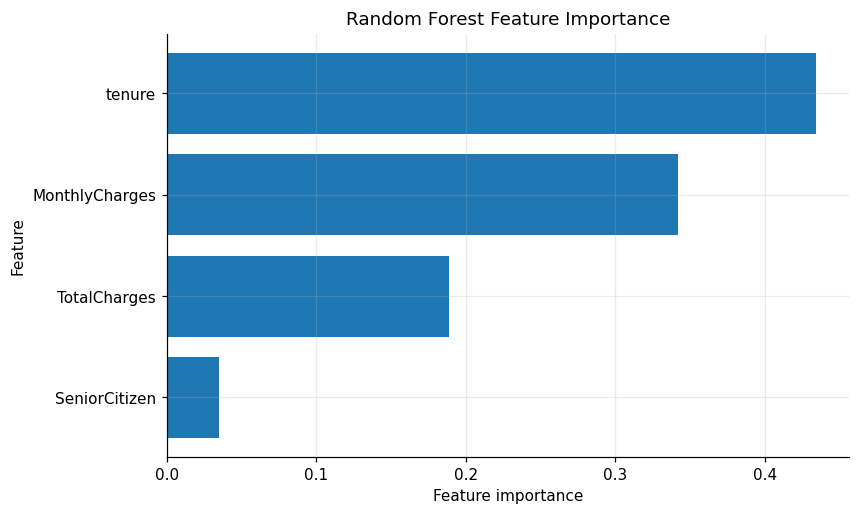

tenure            0.4344
MonthlyCharges    0.3416
TotalCharges      0.1889
SeniorCitizen     0.0351
tenure            0.4344
MonthlyCharges    0.3416
TotalCharges      0.1889
SeniorCitizen     0.0351


In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) pd.Series(values, index=FEATURES) puts a name on every number. Then .sort_values().
# 2) ax.barh(series.index, series.to_numpy()) draws it. Horizontal, so the names are readable.
# 3) Name the series `importances` — the artefact cell and the sanity check both read it.
# 4) Label the x axis with what the number means, not with the attribute name.
# Search: "sklearn feature_importances_ pandas Series barh"
#
# ١) الدالة pd.Series(values, index=FEATURES) تضع اسمًا لكل رقم، ثم ‎.sort_values()‎.
# ٢) والسطر ax.barh(series.index, series.to_numpy()) يرسمها أفقيًّا لتكون الأسماء مقروءة.
# ٣) سمِّ السلسلة `importances` — فخلية الحفظ وفحص النتائج كلاهما يقرؤها.
# ٤) سمِّ المحور الأفقي بما يعنيه الرقم لا باسم الخاصية البرمجية.
# ابحث عن: "sklearn feature_importances_ pandas Series barh"
# ────────────────────────────────────────────────────────────────────

# TODO: Build `importances` from the forest, sort it, and draw it as a horizontal bar chart.
# مهمة: ابنِ `importances` من الغابة، ورتّبها، وارسمها مخطّط أعمدة أفقيًّا.

importances = pd.Series(
    forest.feature_importances_,
    index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    importances.index,
    importances.to_numpy()
)

ax.set_xlabel("Feature importance")
ax.set_ylabel("Feature")
ax.set_title("Random Forest Feature Importance")

plt.show()

print(importances.sort_values(ascending=False).round(4).to_string())

print(importances.sort_values(ascending=False).round(4).to_string())

In [ ]:
# Observation: tenure had the highest feature importance (43.44%), while SeniorCitizen had the lowest (3.51%).
# However, feature importance reflects how the model used the features for splitting, not whether a feature causes churn.
# The different types of features can also affect their importance.

`tenure` comes first and `SeniorCitizen` last, and the last one is worth a second before you conclude
that age does not matter.
It is a 0/1 column, so it offers the tree exactly one possible split; the other three are continuous and
offer hundreds. Importance rewards columns that give a tree many places to cut, which is not the same
thing as rewarding columns that carry information.

So read this chart as *what the model used*, never as *what causes churn*. Those are different claims,
and only the first one is evidence.

<div dir="rtl" align="right">

يأتي `tenure` أوّلًا و`SeniorCitizen` أخيرًا، والأخير يستحقّ وقفة قبل أن تستنتج أن السنّ لا يهمّ. فهو عمود قيمته
صفر أو واحد، أي يقدّم للشجرة انقسامًا واحدًا ممكنًا لا غير؛ بينما الأعمدة الثلاثة الأخرى متّصلة وتقدّم
المئات. والأهمية تكافئ الأعمدة التي تمنح الشجرة مواضع قطع كثيرة، وهذا ليس نفسه مكافأة الأعمدة التي
تحمل معلومة.

فاقرأ هذا المخطّط بوصفه **ما استخدمه النموذج**، لا بوصفه **ما يُسبّب المغادرة**. فهما ادّعاءان مختلفان،
والأول وحده دليل.

</div>

## Section 3 — Stretch: break a column on purpose  (≈10 min)

Open-ended, and lower expectation of completeness. Finish it at home if the room moves on.

There is a blunter way to ask how much a column matters: ruin it and see what happens. Shuffle one
column of the **test** set so its values no longer line up with their rows, score the already-fitted
forest again, and measure the drop. Repeat for each column.

Nothing is refitted. You are damaging the input, not the model.

<div dir="rtl" align="right">

## القسم الثالث — إضافي: أتلِف عمودًا عن قصد (نحو ١٠ دقائق)

مفتوح، والتوقّع فيه أقلّ من حيث الاكتمال. أكمله في المنزل إن مضت القاعة.

هناك طريقة أفظّ للسؤال عن أهمية عمود: أفسِده وانظر ماذا يحدث. اخلط عمودًا واحدًا من مجموعة
**الاختبار** حتى لا تعود قيمه مطابقة لصفوفها، ثم قيّم الغابة المُدرَّبة مسبقًا مرة أخرى، وقِس مقدار
الهبوط. وكرّر ذلك لكل عمود.

ولا يُعاد تدريب شيء. فأنت تُتلف المُدخل لا النموذج.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Copy X_test first — X_test.copy() — or you will corrupt it for every later cell.
# 2) rng.permutation(column_values) returns the same values in a shuffled order.
# 3) The drop is forest_accuracy minus the score on the damaged copy. Store it per column.
# 4) Do NOT call fit. If you refit, you are measuring a different model, not this one.
# Search: "numpy default_rng permutation shuffle column"
#
# ١) انسخ X_test أولًا — X_test.copy() — وإلا أفسدته على كل خلية تالية.
# ٢) الدالة rng.permutation(column_values) تُرجع القيم نفسها بترتيب مخلوط.
# ٣) الهبوط هو forest_accuracy ناقص النتيجة على النسخة المُتلَفة. خزّنه لكل عمود.
# ٤) لا تستدعِ fit. فإن أعدت التدريب فأنت تقيس نموذجًا آخر لا هذا النموذج.
# ابحث عن: "numpy default_rng permutation shuffle column"
# ────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(0)
# TODO: For each column, shuffle it in a copy of X_test and record how far the forest's accuracy falls.
# مهمة: لكل عمود، اخلطه في نسخة من X_test وسجّل كم تهبط دقّة الغابة.

drops = {}

for column in FEATURES:
    damaged = X_test.copy()

    damaged[column] = rng.permutation(
        damaged[column].to_numpy()
    )

    damaged_score = forest.score(damaged, y_test)

    drops[column] = forest_accuracy - damaged_score

for column, drop in sorted(drops.items(), key=lambda item: -item[1]):
    print(f"{column:<16} accuracy falls {drop:+.4f} when shuffled")

tenure           accuracy falls +0.1029 when shuffled
MonthlyCharges   accuracy falls +0.0596 when shuffled
TotalCharges     accuracy falls +0.0121 when shuffled
SeniorCitizen    accuracy falls +0.0085 when shuffled


In [ ]:
# Observation: Shuffling tenure caused the largest accuracy drop (10.29 percentage points), followed by MonthlyCharges (5.96 points).
# This agrees with the feature-importance results and suggests that the forest relied heavily on these two features.

## Save your artefact

`trees_intro.json` records the three accuracies and the depth you chose. Keep it: when you meet trees
again in Week 3 as the baseline a neural network has to beat, this file is what you compare against, and
a number you wrote down beats a number you remember.

<div dir="rtl" align="right">

## احفظ ناتجك

يسجّل الملف `trees_intro.json` الدقّات الثلاث والعمق الذي اخترته. احتفظ به: فحين تلتقي بالأشجار مرة
أخرى في الأسبوع الثالث بوصفها خط الأساس الذي على الشبكة العصبية أن تتفوّق عليه، سيكون هذا الملف هو ما
تقارن به، والرقم المكتوب خير من الرقم المتذكَّر.

</div>

In [ ]:
metrics = {
    "dataset": "telco_churn",
    "features": FEATURES,
    "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
    "majority_baseline": round(MAJORITY, 4),
    "best_depth": int(best_depth),
    "accuracy_one_tree": round(tree_accuracy, 4),
    "accuracy_forest": round(forest_accuracy, 4),
    "most_used_feature": str(importances.idxmax()),
}

out = ARTEFACT_DIR / "trees_intro.json"
out.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(f"Saved {out}")
print(json.dumps(metrics, indent=2))

Saved /content/artefacts/trees_intro.json
{
  "dataset": "telco_churn",
  "features": [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
  ],
  "n_train": 5634,
  "n_test": 1409,
  "majority_baseline": 0.7346,
  "best_depth": 5,
  "accuracy_one_tree": 0.7885,
  "accuracy_forest": 0.7949,
  "most_used_feature": "tenure"
}


In [ ]:
from google.colab import files

files.download("/content/artefacts/trees_intro.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# The artefact preserves the selected tree depth and the final test accuracies,
# giving me a reproducible baseline to compare with future models.

## Sanity check

Run this last. Every check that fails tells you what to fix and why.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

</div>

In [ ]:
# --- Sanity checks ----------------------------------------------------------------
check(small_tree.get_depth() <= 2,
      f"the warm-up tree must be 2 questions deep at most, yours is {small_tree.get_depth()} — "
      f"check you passed max_depth=2",
      f"يجب ألا يتجاوز عمق شجرة الإحماء سؤالين، وعمق شجرتك {small_tree.get_depth()} — "
      f"تحقّق أنك مرّرت max_depth=2")

check(len(train_scores) == 10 and len(test_scores) == 10,
      f"the sweep needs one score per depth 1-10: got {len(train_scores)} train and "
      f"{len(test_scores)} test",
      f"يحتاج المسح نتيجة لكل عمق من ١ إلى ١٠: لديك {len(train_scores)} للتدريب و"
      f"{len(test_scores)} للاختبار")

check(train_scores[-1] > train_scores[0],
      f"a deeper tree must fit the TRAINING data better: depth 1 gives {train_scores[0]:.4f}, "
      f"depth 10 gives {train_scores[-1]:.4f} — if not, you scored the test half twice",
      f"يجب أن تُطابق الشجرة الأعمق بيانات **التدريب** أفضل: العمق ١ يعطي {train_scores[0]:.4f} "
      f"والعمق ١٠ يعطي {train_scores[-1]:.4f} — وإلا فقد قيّمت نصف الاختبار مرتين")

check(train_scores[-1] - test_scores[-1] > 0.01,
      f"at depth 10 the train-test gap should be visible; yours is "
      f"{train_scores[-1] - test_scores[-1]:.4f}",
      f"عند العمق ١٠ يجب أن تكون الفجوة بين التدريب والاختبار ظاهرة، وفجوتك "
      f"{train_scores[-1] - test_scores[-1]:.4f}")

check(forest_accuracy > MAJORITY,
      f"the forest should beat 'nobody leaves': {forest_accuracy:.4f} vs {MAJORITY:.4f} — "
      f"if it does not, check you fitted on the TRAINING half",
      f"يجب أن تتفوّق الغابة على «لا أحد يغادر»: {forest_accuracy:.4f} مقابل {MAJORITY:.4f} — "
      f"وإن لم يحدث فتحقّق أنك درّبت على نصف التدريب")

check(abs(float(importances.sum()) - 1.0) < 1e-6,
      f"the four importances must add up to 1, yours add to {float(importances.sum()):.6f}",
      f"يجب أن يكون مجموع الأهمّيات الأربع واحدًا، ومجموعك {float(importances.sum()):.6f}")

check((ARTEFACT_DIR / "trees_intro.json").exists(),
      "trees_intro.json should exist — run the save cell above",
      "يجب أن يوجد الملف trees_intro.json — شغّل خلية الحفظ أعلاه")

report()

──────────────────────────────────────────────────────────────────
  ✓  the warm-up tree must be 2 questions deep at most, yours is 2 — check you passed max_depth=2
  ✓  the sweep needs one score per depth 1-10: got 10 train and 10 test
  ✓  a deeper tree must fit the TRAINING data better: depth 1 gives 0.7346, depth 10 gives 0.8608 — if not, you scored the test half twice
  ✓  at depth 10 the train-test gap should be visible; yours is 0.1135
  ✓  the forest should beat 'nobody leaves': 0.7949 vs 0.7346 — if it does not, check you fitted on the TRAINING half
  ✓  the four importances must add up to 1, yours add to 1.000000
  ✓  trees_intro.json should exist — run the save cell above
──────────────────────────────────────────────────────────────────
  ✅ All 7 checks passed. / اجتزت جميع الفحوصات (7).
──────────────────────────────────────────────────────────────────


## What's next

You now have two ways to draw a boundary: one straight line from logistic regression, and a staircase of
axis-aligned boxes from a tree. The other extra lab today, `D4_extra_svm`, adds a third — a boundary
that can curve — and asks what it costs.

<div dir="rtl" align="right">

## ماذا بعد

صار لديك الآن طريقتان لرسم حدّ القرار: خطّ مستقيم واحد من الانحدار اللوجستي، وسُلّم من الصناديق
المحاذية للمحاور من الشجرة. والمعمل الإضافي الآخر اليوم، `D4_extra_svm`، يضيف ثالثة — حدًّا يستطيع أن
ينحني — ويسأل عن ثمنها.

</div>